# Wasserstein K-Means

## Market regime detection for one index or stock

In [1]:
import sys

sys.path.append("..")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import trange
from scipy.stats import kstest, levene

In [145]:
%load_ext autoreload
%autoreload 2

from market_regime_detection.data import load_yf_data, compute_log_returns

from market_regime_detection.wasserstein_univariate import (
    split_array_into_windows,
    wasserstein_k_means,
    get_corrected_assignments,
)

from market_regime_detection.qlr_test import detect_mean_breaks, detect_variance_breaks

from market_regime_detection.chow_test import chow_test, create_timeseries_x

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading data

In [4]:
TICKER = "^GSPC"

In [5]:
date_from = "2016-01-01"
date_to = "2026-01-01"

In [6]:
market_data = load_yf_data(tickers=TICKER, date_from=date_from, date_to=date_to)

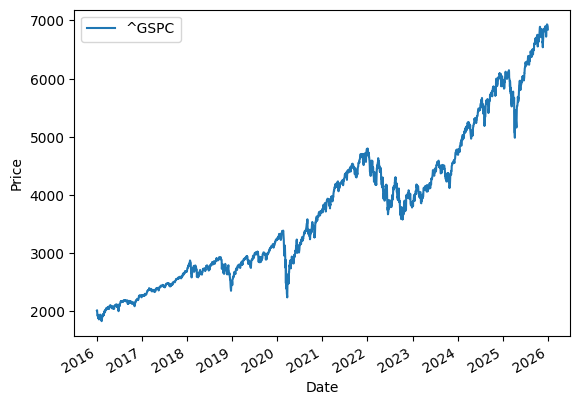

In [7]:
market_data.plot()
plt.ylabel("Price")
plt.xlabel("Date")
plt.show()

Exactly 252 trading days on average

In [8]:
market_data.index.year.value_counts()

Date
2020    253
2016    252
2021    252
2019    252
2024    252
2017    251
2018    251
2022    251
2023    250
2025    250
Name: count, dtype: int64

Compute log-returns

In [9]:
market_returns = market_data.apply(compute_log_returns, axis=0)
market_returns = market_returns.set_index(market_data.index[1:].floor("d"))

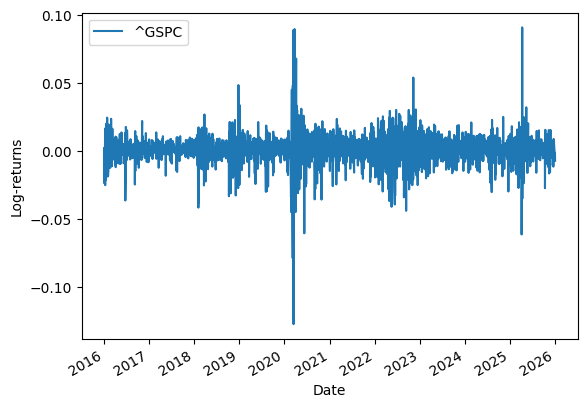

In [10]:
market_returns.plot()
plt.ylabel("Log-returns")
plt.xlabel("Date")
plt.show()

## Clusterization

In [11]:
WINDOW_LENGTH_DAYS = 40  # ~ 2 months

In [12]:
data_for_clustering = split_array_into_windows(
    market_returns=market_returns[TICKER].to_numpy(), window_shape=WINDOW_LENGTH_DAYS
)

- 2 clusters - bull and bear market
- 3 clusters - bull / neutral / stress
- 4+ clusters - volatility clustering / finer market regimes

In [22]:
final_clusters = {}

for num_clusters in trange(2, 5):

    assignments, _, _ = wasserstein_k_means(
        chunks=data_for_clustering, n_clusters=num_clusters, max_iter=100
    )

    corrected_assignments = get_corrected_assignments(
        assignments=assignments, window_shape=WINDOW_LENGTH_DAYS
    )

    final_clusters[num_clusters] = corrected_assignments

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:26<00:00,  8.80s/it]


In [14]:
np.bincount(final_clusters[3])

array([ 434, 1318,  722])

In [15]:
# np.unique(assignments, return_counts=True)

## Visualization

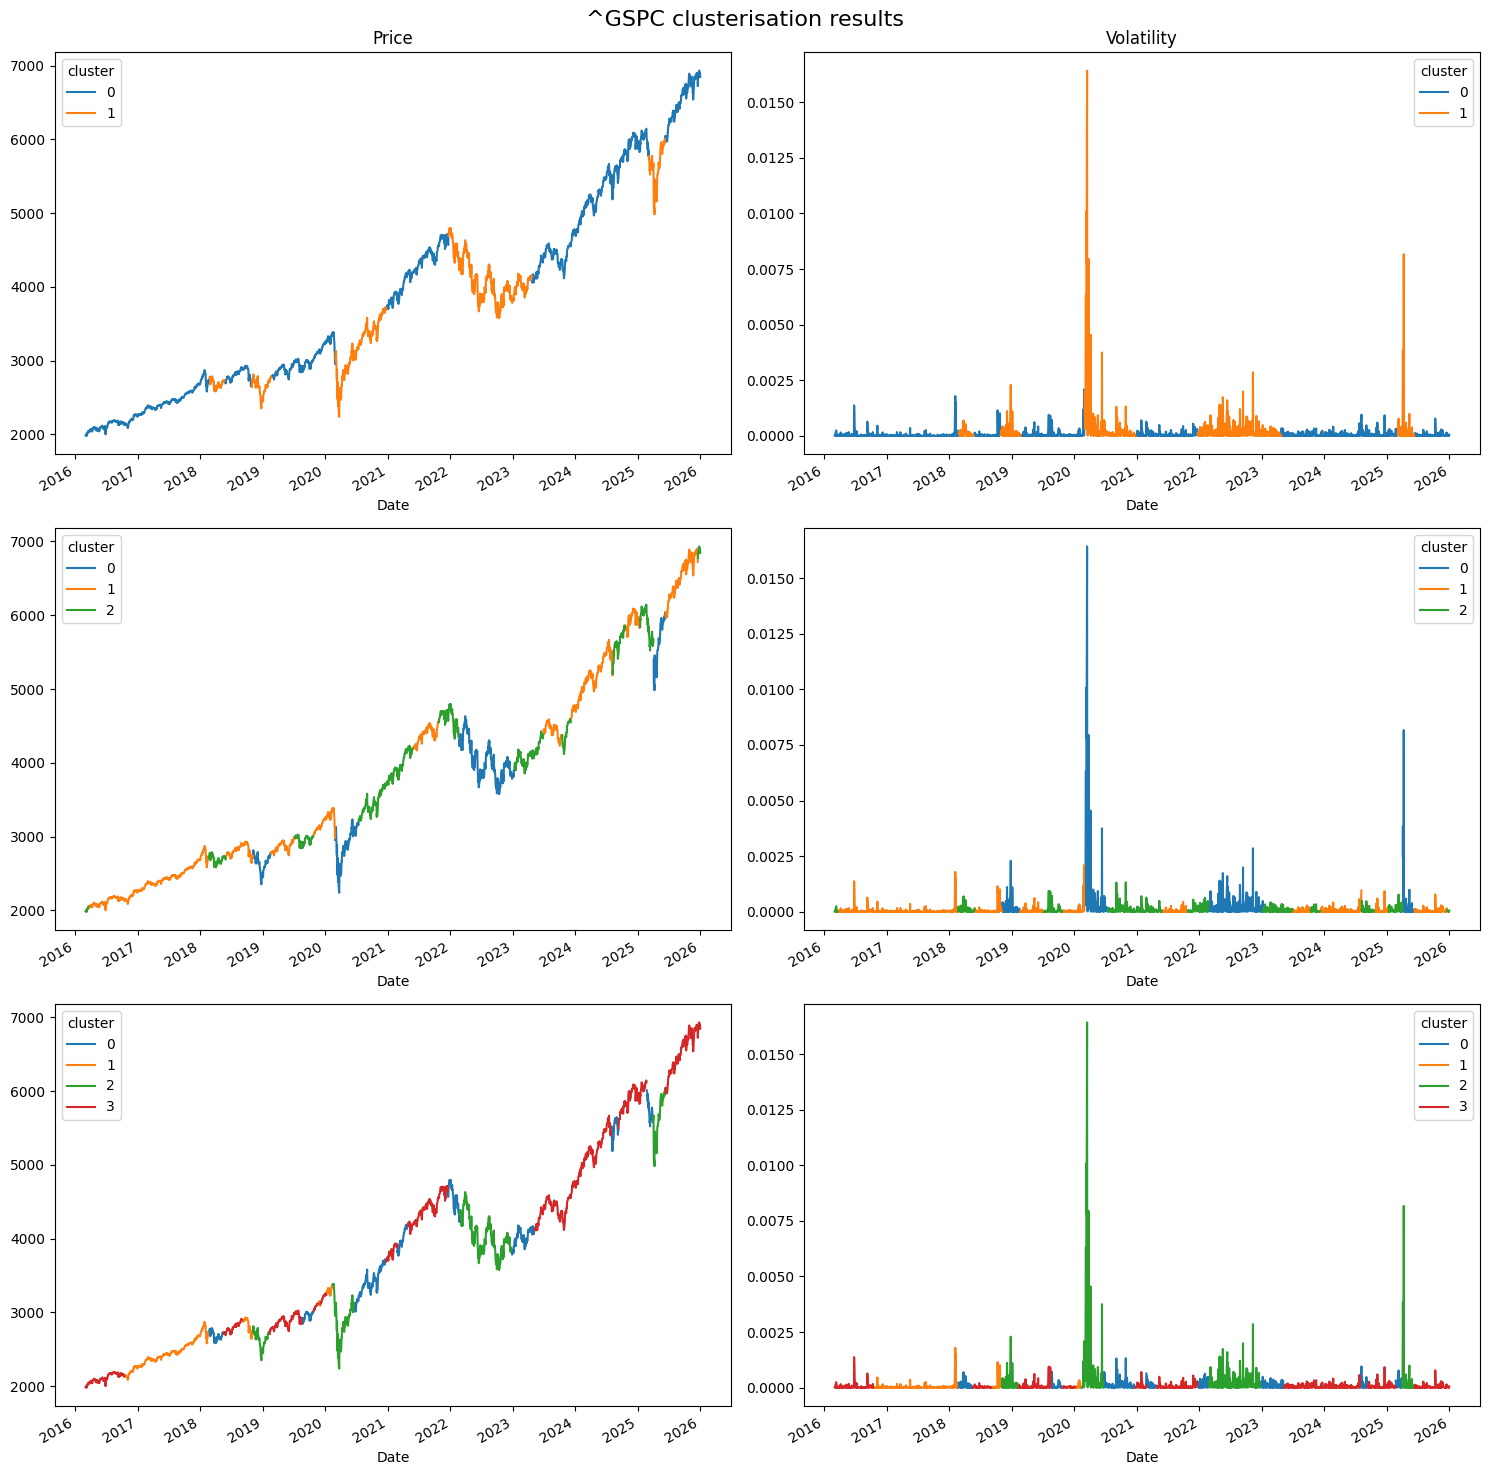

In [16]:
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

for n_clusters, cluster_assignment in final_clusters.items():

    (
        market_data.iloc[WINDOW_LENGTH_DAYS:, :]
        .assign(cluster=cluster_assignment)
        .reset_index()
        .pivot(index="Date", columns="cluster", values=TICKER)
        .plot(ax=axs[n_clusters - 2, 0])
    )

    (
        market_returns.iloc[WINDOW_LENGTH_DAYS - 1 :, :]
        .apply(lambda x: (x - np.mean(x)) ** 2)
        .assign(cluster=cluster_assignment)
        .reset_index()
        .pivot(index="Date", columns="cluster", values=TICKER)
        .plot(ax=axs[n_clusters - 2, 1])
    )

axs[0, 0].set_title("Price")
axs[0, 1].set_title("Volatility")
fig.suptitle(f"{TICKER} clusterisation results", fontsize=16)

plt.tight_layout()
plt.show()

It seems that two-cluster approach works the best, while 3- and 4-cluster ones need more fine-tuning

## Compare with QLR test

### Mean

In [100]:
%%time
breakpoints_idx, n_breakpoints = detect_mean_breaks(
    y=market_data[TICKER].to_numpy(),
    max_breaks=10,
    min_segment=20,
)

[np.float64(36029.6355744966), np.float64(32950.246076901996), np.float64(30214.3085994308), np.float64(29289.907391679197), np.float64(28311.329643038815), np.float64(27851.367375000515), np.float64(27327.882354519053), np.float64(27041.276168227385), np.float64(26624.048005106848), np.float64(26215.830614506023), np.float64(25932.441917647535)]
CPU times: total: 2min 49s
Wall time: 2min 50s


In [101]:
breakpoints_idx

[235, 451, 815, 1155, 1321, 1592, 1866, 2026, 2168, 2387]

In [117]:
plot_data = market_data.assign(cluster=0).reset_index()

In [118]:
for i in np.arange(0, len(breakpoints_idx), 2):
    plot_data.iloc[breakpoints_idx[i] : breakpoints_idx[i + 1], -1] = 1

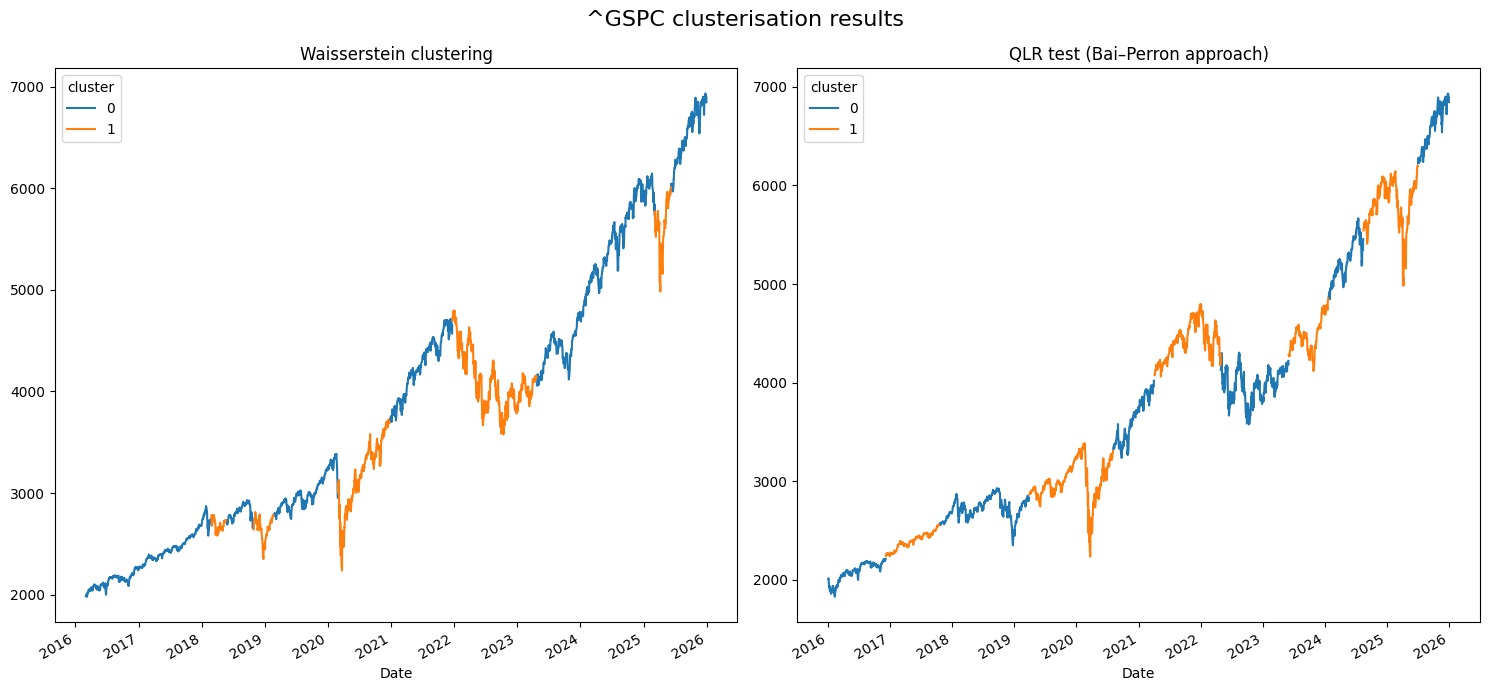

In [123]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

cluster_assignment = final_clusters[2]

(
    market_data.iloc[WINDOW_LENGTH_DAYS:, :]
    .assign(cluster=cluster_assignment)
    .reset_index()
    .pivot(index="Date", columns="cluster", values=TICKER)
    .plot(ax=axs[0])
)

plot_data.pivot(index="Date", columns="cluster", values=TICKER).plot(ax=axs[1])

axs[0].set_title("Waisserstein clustering")
axs[1].set_title("QLR test (Bai–Perron approach)")
fig.suptitle(f"{TICKER} clusterisation results", fontsize=16)

plt.tight_layout()
plt.show()

Results resemble each other, but the suggested Wassertein-based approach is more interpretable and looks better

### Variance

In [124]:
%%time
breakpoints_idx, n_breakpoints = detect_variance_breaks(
    y=market_returns[TICKER].to_numpy(),
    max_breaks=10,
    min_segment=20,
)

[np.float64(15.658465075087184), np.float64(23.487697612630775), np.float64(31.316930150174368), np.float64(39.14616268771796), np.float64(46.97539522526155), np.float64(54.80462776280515), np.float64(62.633860300348736), np.float64(70.46309283789233), np.float64(78.29232537543592), np.float64(86.12155791297951), np.float64(93.9507904505231)]
CPU times: total: 2min 53s
Wall time: 2min 55s


QLR test suggests no breakpoints in variance of returns

### Chow test

H0: no breakpoint

H1: breakpoint

In [418]:
test_data = market_data.iloc[WINDOW_LENGTH_DAYS:, :]

In [419]:
test_index = np.arange(WINDOW_LENGTH_DAYS, test_data.shape[0], 1)

In [420]:
p_value = []

for value in test_index:

    y = test_data.iloc[value - WINDOW_LENGTH_DAYS : value + WINDOW_LENGTH_DAYS, :]
    y = y[TICKER].to_numpy()

    if len(y) < WINDOW_LENGTH_DAYS * 2:
        break

    X = create_timeseries_x(y.shape[0] - 1)
    X = np.hstack([X, y[:-1][:, np.newaxis]])

    single_p_val = chow_test(y[1:], X, 40)[1]

    p_value.append(single_p_val)

In [421]:
breakpoint_detected = np.array(p_value) < 0.10
breakpoints_idx = np.where(np.diff(breakpoint_detected) == 1)
breakpoints_idx = np.insert(breakpoints_idx[0], 0, 0)
breakpoints_idx = breakpoints_idx[np.where(np.diff(breakpoints_idx) > 1)[0]]

In [422]:
# breakpoints_idx

In [423]:
plot_data = (
    market_data.iloc[WINDOW_LENGTH_DAYS:]
    .assign(cluster=final_clusters[2])
    .iloc[-len(p_value) :]
    .assign(chow_clusters=1)
)

In [424]:
for i in np.arange(1, len(breakpoints_idx) - 1, 2):
    plot_data.iloc[breakpoints_idx[i - 1] : breakpoints_idx[i], -1] = 0

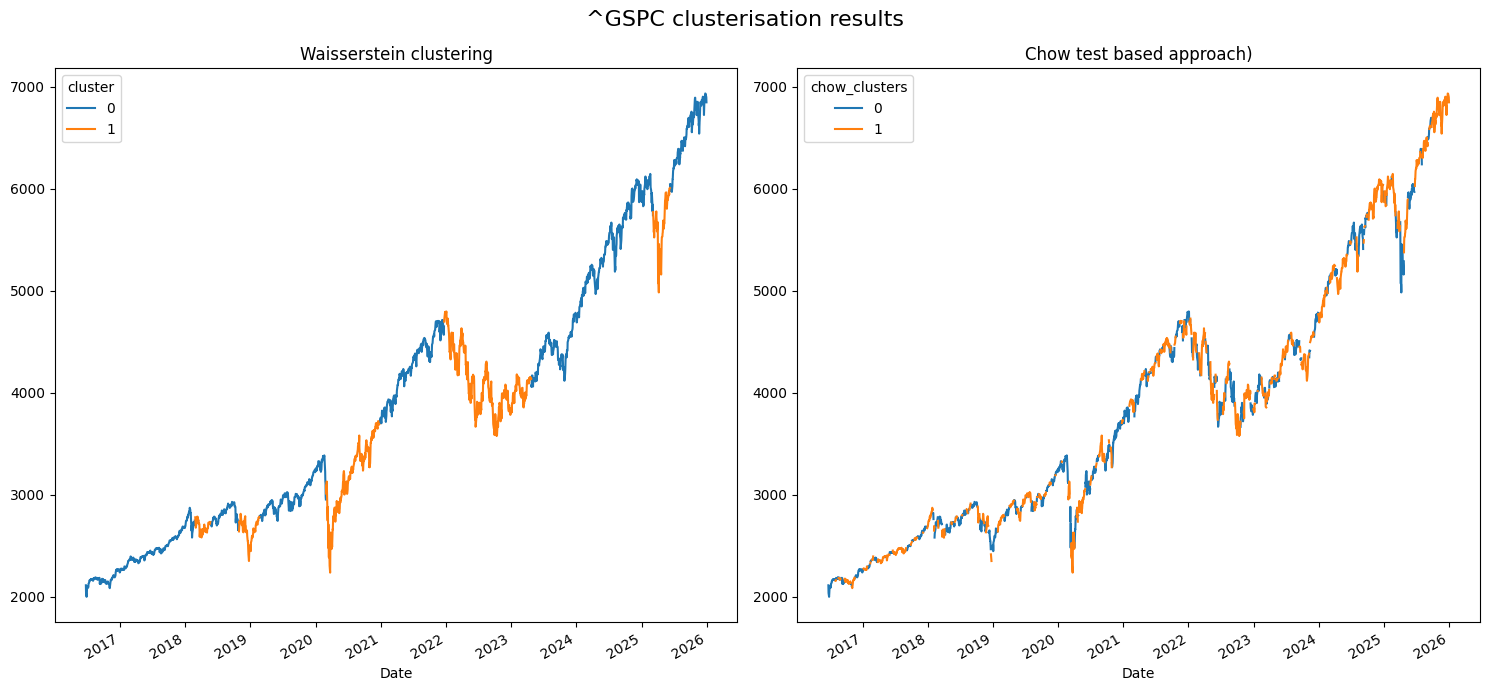

In [425]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

plot_data.reset_index().pivot(index="Date", columns="cluster", values=TICKER).plot(
    ax=axs[0]
)

plot_data.reset_index().pivot(
    index="Date", columns="chow_clusters", values=TICKER
).plot(ax=axs[1])

axs[0].set_title("Waisserstein clustering")
axs[1].set_title("Chow test based approach)")
fig.suptitle(f"{TICKER} clusterisation results", fontsize=16)

plt.tight_layout()
plt.show()

Chow test allows us to estimate breakpoints but not to tell what number of clusters we should choose. 

Perhaps if we combine it with Wasserstein K-Means approach, we can benefit from using it 

### Chow test [2]

In [426]:
wasserstein_breakpoints = np.where(plot_data["cluster"].diff().abs() == 1)[0]

In [427]:
wasserstein_breakpoints

array([ 421,  481,  592,  669,  927, 1135, 1385, 1720, 2188, 2253])

In [431]:
p_values = []

for x in np.arange(0, len(wasserstein_breakpoints), 2):

    start = wasserstein_breakpoints[x]
    breakpoint_idx = wasserstein_breakpoints[x + 1]

    if x + 2 >= len(wasserstein_breakpoints):
        end = test_data.shape[0]
    else:
        end = wasserstein_breakpoints[x + 2]

    y = plot_data.iloc[start:end, 0].to_numpy()
    X = create_timeseries_x(y.shape[0] - 1)
    X = np.hstack([X, y[:-1][:, np.newaxis]])

    log_ret = np.diff(np.log(y))

    test_res = {
        "Chow": chow_test(y[1:], X, break_idx=breakpoint_idx - start)[1],
        "Levene": levene(log_ret[:breakpoint_idx - start], log_ret[breakpoint_idx - start:]).pvalue,
        "KS": kstest(log_ret[:breakpoint_idx - start], log_ret[breakpoint_idx - start:]).pvalue
    }
        
    p_values.append(test_res)

In [432]:
pd.DataFrame(p_values).round(2)

,Chow,Levene,KS
0,0.03,0.01,0.28
1,0.82,0.00,0.15
2,0.01,0.00,0.00
3,0.08,0.00,0.00
4,0.05,0.00,0.20


Most of the P-values are less than 10%, therefore we can say that the method works